In [1]:
# Basic set of Python Data Analysis
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas(desc="Progress")

## for plot by matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import itertools
from cycler import cycler
import seaborn as sns

# for plot by matplotlib
sns.set(font="Serif", font_scale=2.0,
        rc={'figure.figsize': (10, 10),
            'lines.markersize': 15,
            "animation.embed_limit": 100})
sns.set_style('darkgrid', {'axes.facecolor': "0.8"})

## don't show warning
import warnings
warnings.filterwarnings('ignore')

# import the Escal Tools
import os, sys
sys.path.append(os.path.expanduser("toolkits"))

In [ ]:
%load_ext autoreload
%autoreload 2
import basicTools as btls

# Setup and Read data

In [3]:
## the data directory
filePref = filePref=f"data/Chignolin_375-dih"
print("The analysis will do for: \n", filePref)

## set the feature
feature = "dih"  #dih or dist

### similar metrix
similar = bt.dist.cosin

### smooth
step    = 100
width   = 200
seg2vec = bt.segment.mean

### evalute method
evalute = bt.evalute.cluster

The analysis will do for: 
 data/Chignolin_375-dih


In [4]:
import pickle
# read data from file
data = pickle.load(open(f"{filePref}.pkl", 'rb'))
# setup data variables
rescl = data["rescl"]
efft = data["efft"]
sal = data["saliency"]
qmc = data["qmc"]
rms = data["rms"]
netname = data['net']
args = data['args']
# paramenters
tTotal = 0.5/efft.ufreq

# RMSD from Native Structure

Text(0.5, 0, 'RMSD (nm)')

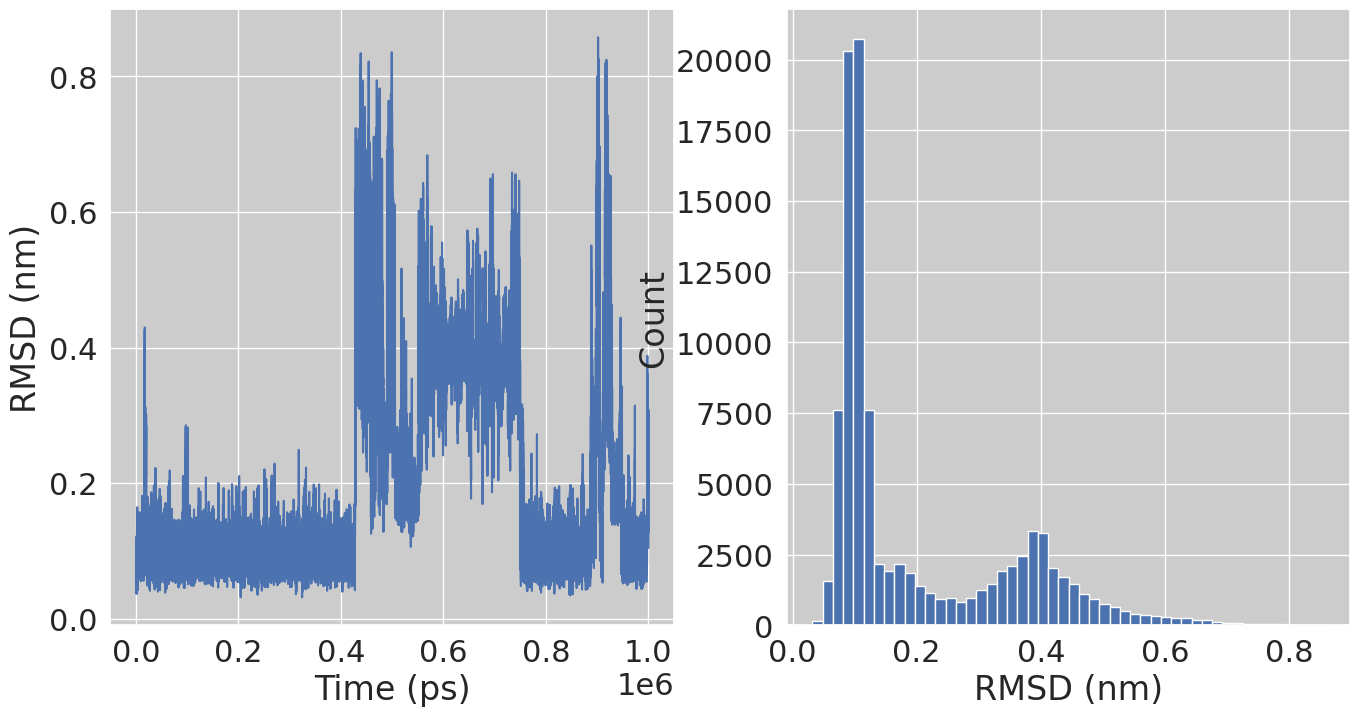

In [5]:
plt.figure(12,figsize=(16,8))
ax = plt.subplot(121)
ax.plot(rms['time'], rms['rms'])
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (nm)")
ax = plt.subplot(122)
hist = ax.hist(rms["rms"], bins=50)
plt.ylabel("Count")
plt.xlabel("RMSD (nm)")

# Score of Kappa

Text(0, 0.5, 'QMC')

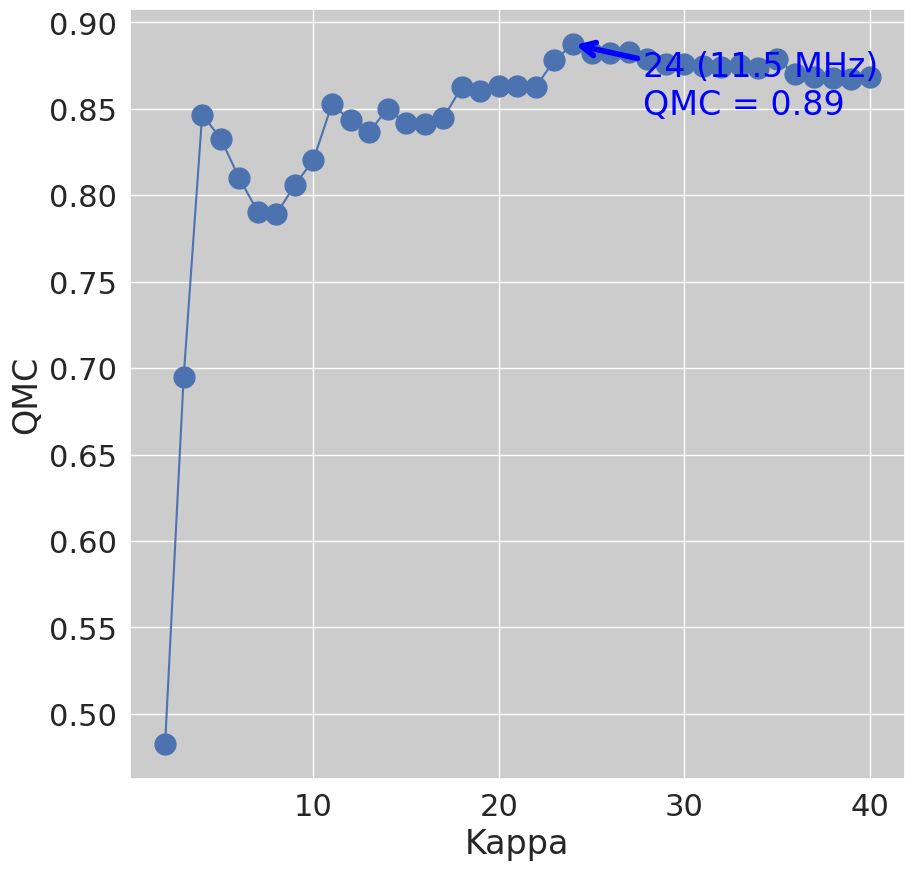

In [6]:
## plot the multiple correlation coefficient
plt.plot(qmc['list'][:,0],qmc['list'][:,1], marker="o")

## annotate the peak value
xy     = (qmc['KappaMax'], qmc['qmcMax'])
offset = 0.1 * (np.max(qmc['list'], axis=0)-np.min(qmc['list'],axis=0))
xytxt  = [xy[0] + offset[0], xy[1] - offset[1]]
plt.annotate(f"{int(xy[0]):2d} ({(xy[0]-1)*efft.ufreq:.1f} MHz)\nQMC = {xy[1]:.2f}",
            xy=xy, xytext=xytxt, color='blue', 
            arrowprops=dict(arrowstyle="->", color='blue', lw=4))
plt.xlabel("Kappa")
plt.ylabel("QMC")

# Weight of Features

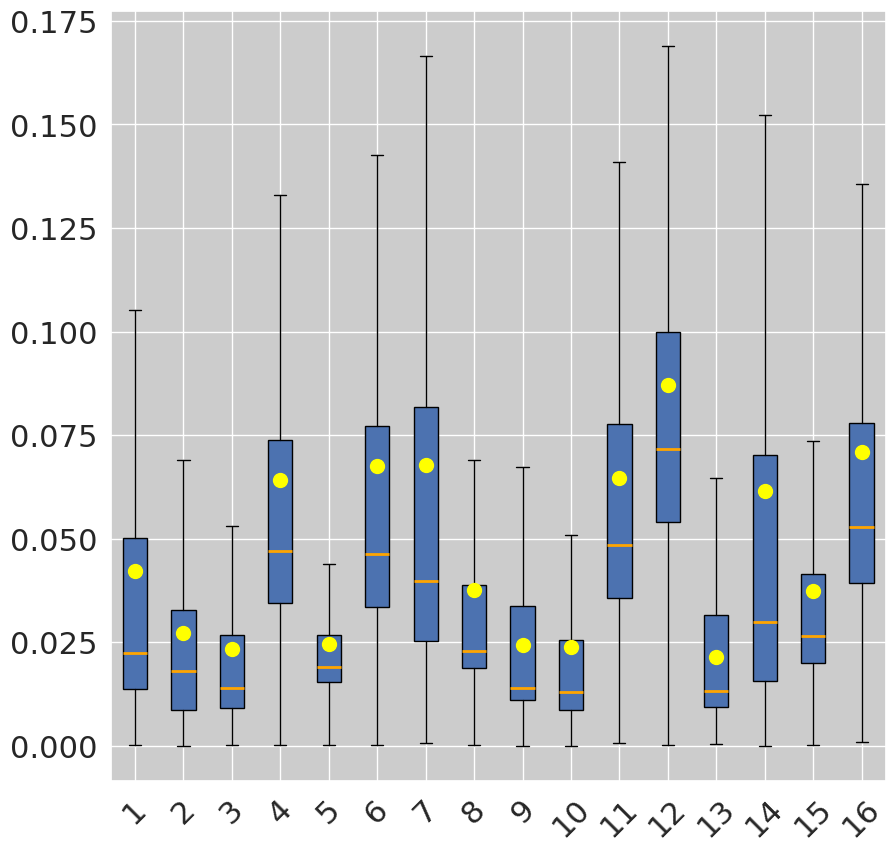

In [7]:
if sal is None:
    bt.plot.coefplot(bt.feature.dihCombind(rescl['A']) if feature == "dih" else rescl['A'])
else:
    if feature == 'dih':
        sal = bt.feature.dihCombind(sal)
    bt.plot.saliplot(sal.T)

# Effective Energy

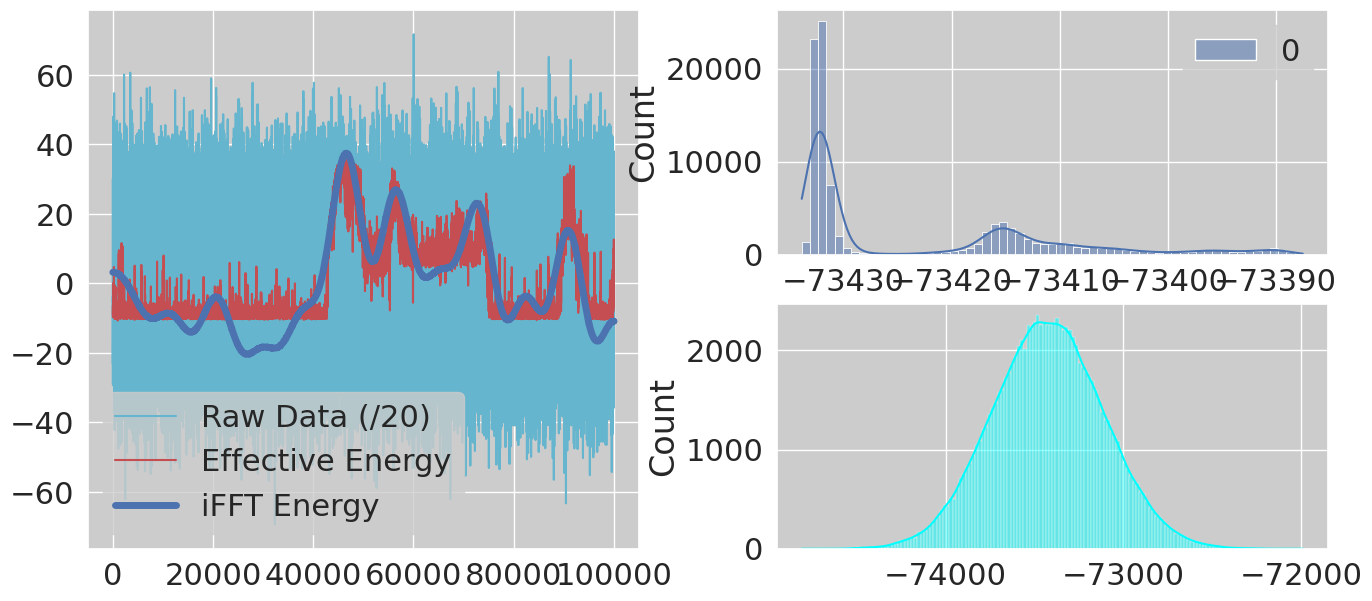

In [8]:
## plot the effective energy
bt.plot.efplot(efft.E0, efft.Ef(args.kappa), rescl['Ee'])

# Distribution & Free Energy

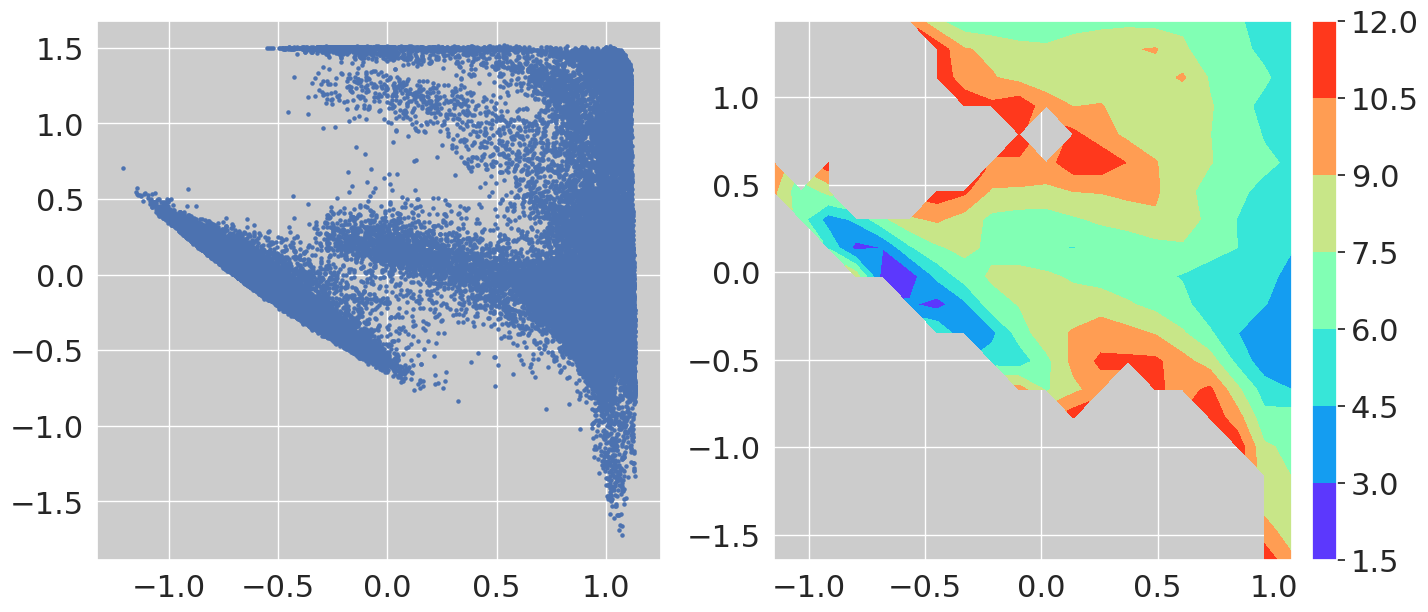

In [9]:
from sklearn.decomposition import PCA

if rescl['X'].shape[1] == 2:
    bt.plot.distr_plot(rescl['X'])
else:
    ## plot by PCA eigen vector
    pca = PCA()
    bt.plot.distr_plot(pca.fit_transform(rescl['X'])[:, :2])
    plt.plot(pca.explained_variance_)

# Similar Matrix

In [10]:
## get the samples
X0s = seg2vec(efft.Xx, step, width)
Xys = seg2vec(rescl['X'], step, width)

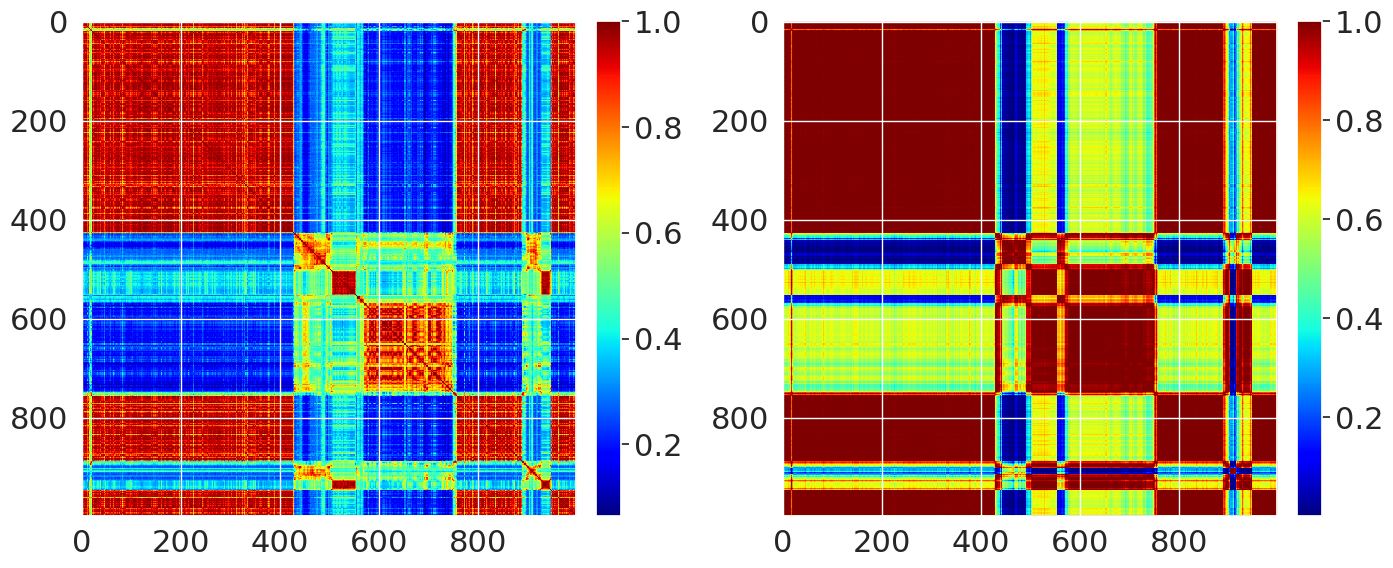

In [11]:
## set distance function and get distance
Smat0  = similar(X0s)
Smaty  = similar(Xys)
    
### plot
fig, axs = plt.subplots(1,2, figsize=(16,32)) 
fig.subplots_adjust(wspace=0.3)
bt.plot.implot(Smat0, axs[0])
bt.plot.implot(Smaty, axs[1])

# Matrix Analysis

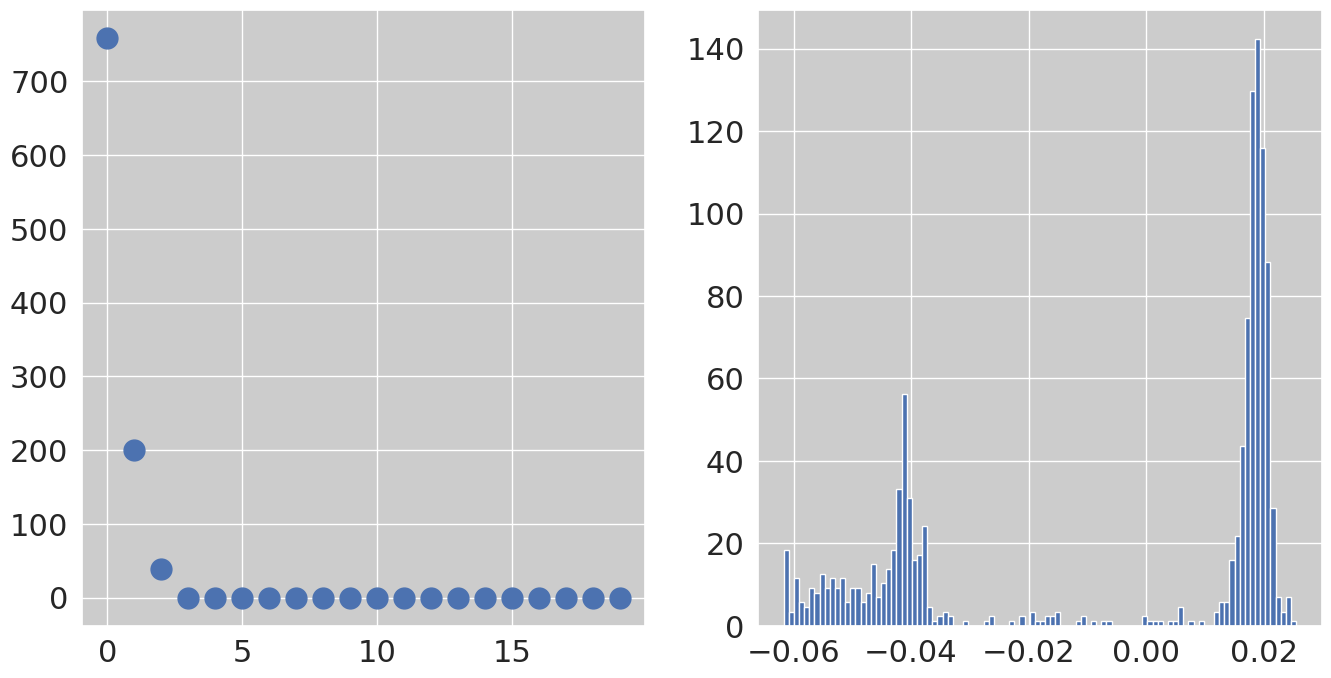

In [12]:
w,v = np.linalg.eig(Smaty)

fig, axs = plt.subplots(1,2, figsize=(16,8)) 
axs[0].plot(w[0:20], "o")
hist = axs[1].hist(v[:,1], bins=100, density=True)

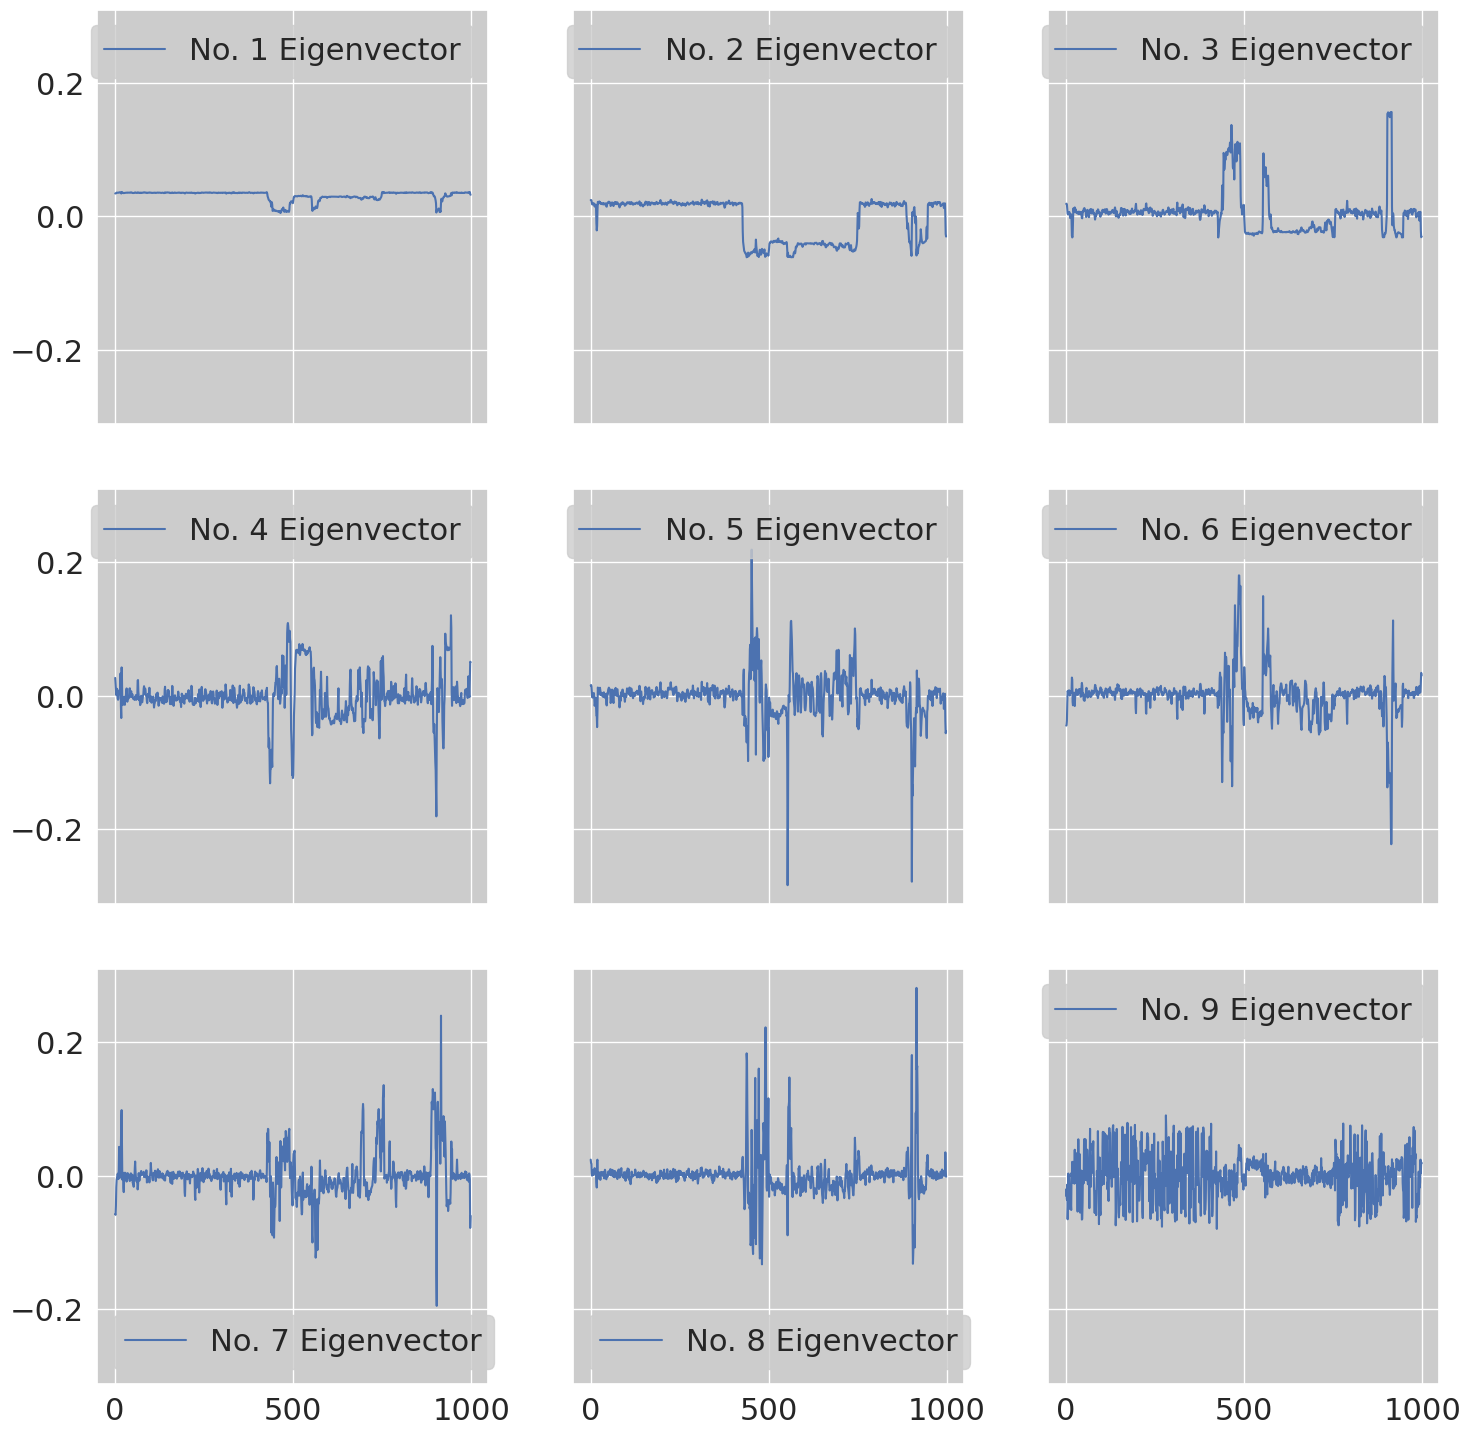

In [13]:
fig, axs = plt.subplots(3,3,sharex=True,sharey=True, figsize=(15,15)) 
sel = range(0,np.size(axs))
fig.tight_layout()
for ax, key in zip(axs.reshape(len(sel)), sel): 
    ax.plot(v[:,key])
    ax.legend(labels =["No. " + str(key+1) + " Eigenvector"])

# Clustering by Kmeans

In [14]:
from sklearn.cluster import KMeans

In [15]:
## Test KMean parameters
def testKMn(n):
    cl = KMeans(n_clusters=n,n_init=50).fit_predict(Xys)
    return evalute(Xys, cl)

score_KMean = pd.DataFrame({'ncluster':np.arange(2,10)})
score_KMean['score'] = score_KMean['ncluster'].apply(testKMn)

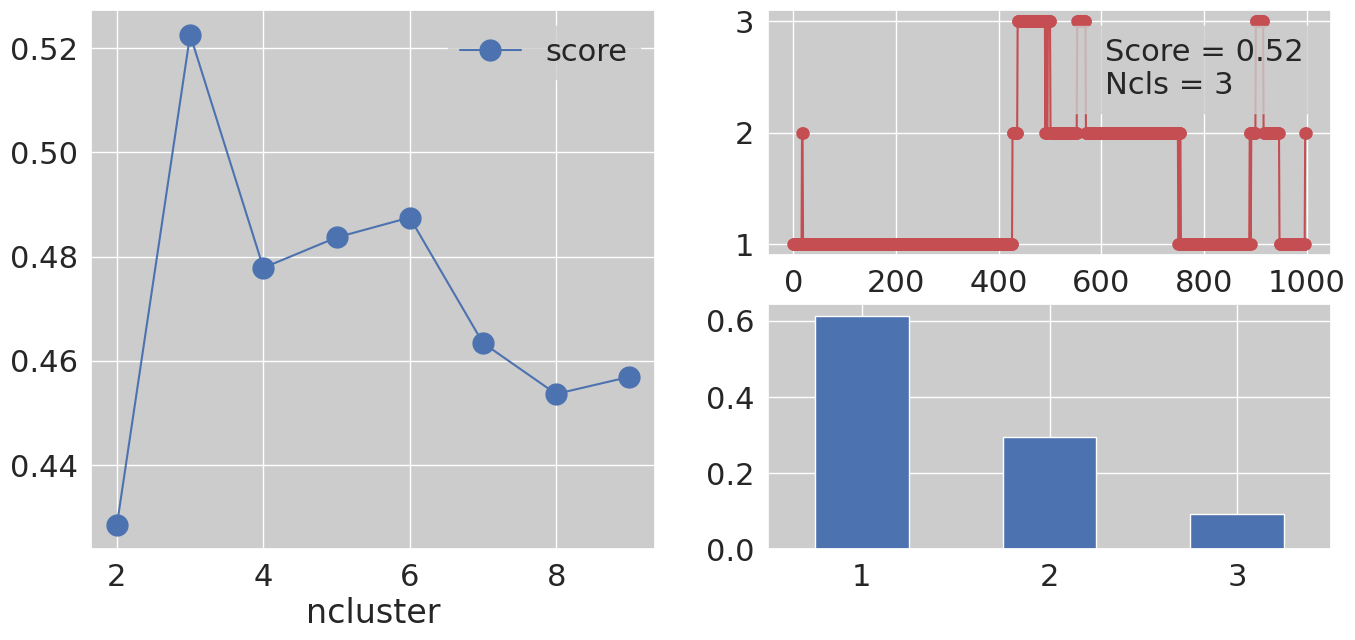

In [16]:
idxPeak = score_KMean['score'].idxmax();
ncls = score_KMean.loc[idxPeak,'ncluster']
cl = KMeans(n_clusters=ncls,n_init=50).fit_predict(Xys)
score = evalute(Xys, cl)

## plot data
lab = f"Score = {score:.2f}\nNcls = {ncls}"
bt.plot.clplot(score_KMean.set_index('ncluster'), cl, lab)